<a href="https://colab.research.google.com/github/tayLorGeniuszhang017676/Evolutron/blob/master/Book_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.cumulative return and long - short analysis **

请输入 QCOM US Equity 的权重（正为Long，负为Short，如1 或 -1）: -1
请输入 FN US Equity 的权重（正为Long，负为Short，如1 或 -1）: 1


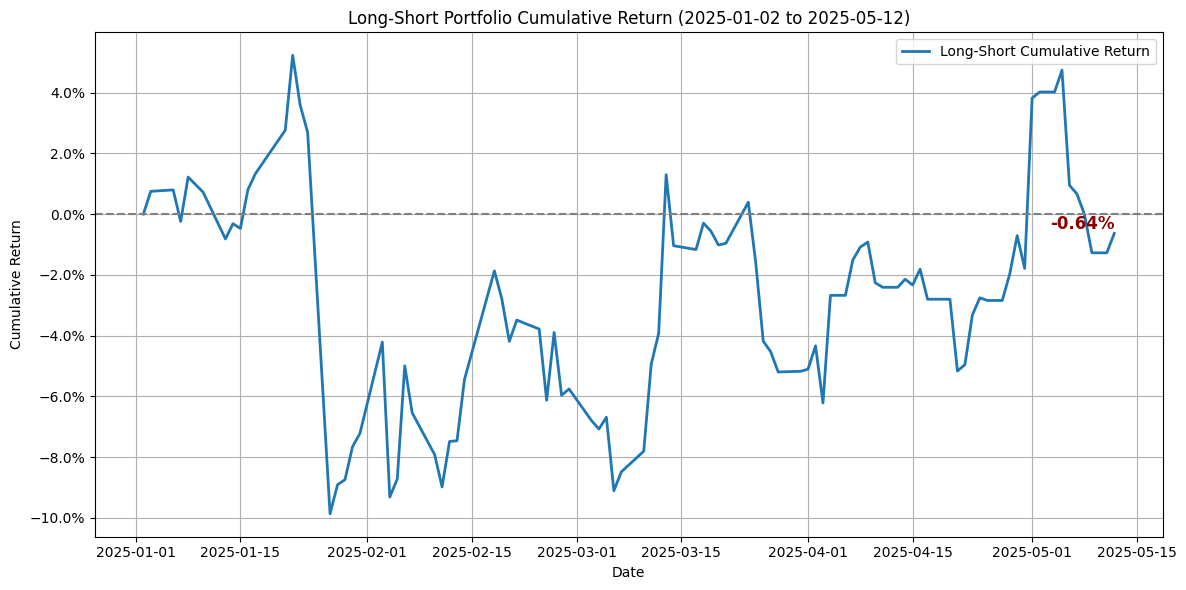

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# === Step 1: 读取 Excel 文件 ===
file_path = 'stock daily data.xlsx'
df = pd.read_excel(file_path, skiprows=2)

# === Step 2: 清洗数据（列名 + 日期索引）===
df = df.dropna(axis=1, how='all')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.set_index('Date')
df.columns = df.columns.str.strip()
df = df.sort_index()

# === Step 3: 限定分析时间段 ===
df = df.loc['2025-01-02':'2025-05-12']

# === Step 4: 设置 Long / Short 股票和权重 ===
# 你可以在这里自定义或手动输入
selected_stocks = ['QCOM US Equity', 'FN US Equity']
weights = {}

# 可选：让用户手动输入权重
for stock in selected_stocks:
    w = float(input(f"请输入 {stock} 的权重（正为Long，负为Short，如1 或 -1）: "))
    weights[stock] = w

# 自动归一化权重（可选）
total = sum(abs(v) for v in weights.values())
weights = {k: v / total for k, v in weights.items()}

# === Step 5: 筛选并归一化价格 ===
df_portfolio = df[selected_stocks].dropna().astype(float)
normalized_prices = df_portfolio / df_portfolio.iloc[0]  # 归一化
relative_returns = normalized_prices - 1  # 起点为 0%

# === Step 6: 计算组合累计收益 ===
weight_vector = [weights[ticker] for ticker in selected_stocks]
cumulative_return = relative_returns.mul(weight_vector, axis=1).sum(axis=1)

# === Step 7: 绘图 ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_return, label='Long-Short Cumulative Return', linewidth=2)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Long-Short Portfolio Cumulative Return (2025-01-02 to 2025-05-12)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(True)

# 标注最后一个收益点
last_date = cumulative_return.index[-1]
last_value = cumulative_return.iloc[-1]
plt.text(last_date, last_value,
         f'{last_value:.2%}',
         fontsize=12, fontweight='bold',
         color='darkred', ha='right', va='bottom')

plt.tight_layout()
plt.show()


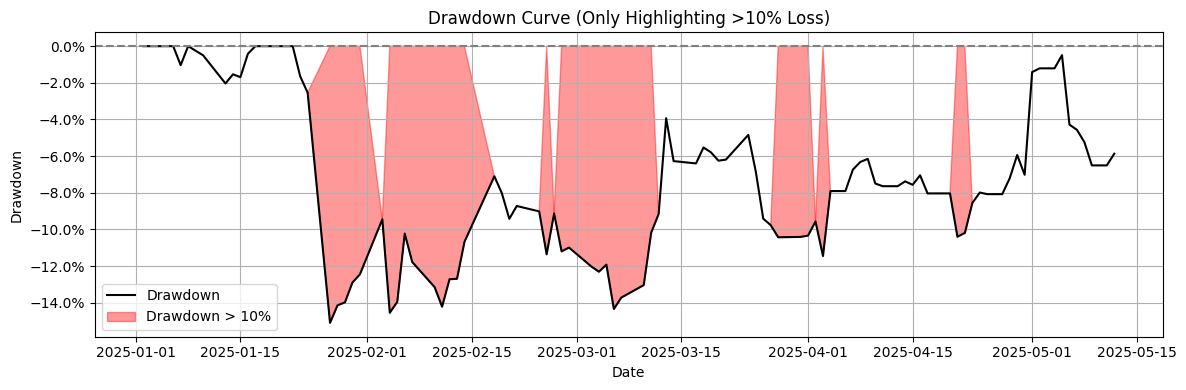

In [12]:
# === Step 9: 精修版 Drawdown 曲线，只标注超过 10% 的回撤 ===
plt.figure(figsize=(12, 4))
plt.plot(drawdown, color='black', linewidth=1.5, label='Drawdown')

# 只填充 drawdown <= -10% 的部分
critical_drawdown = drawdown <= -0.10
plt.fill_between(drawdown.index, drawdown, 0,
                 where=critical_drawdown,
                 interpolate=True,
                 color='red', alpha=0.4, label='Drawdown > 10%')

# 横线 & 样式
plt.axhline(0, linestyle='--', color='gray')
plt.title(f'Drawdown Curve (Only Highlighting >10% Loss)')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


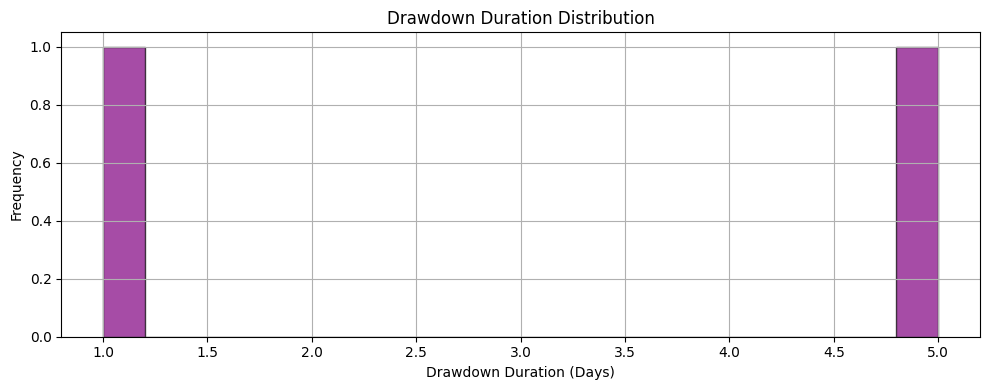

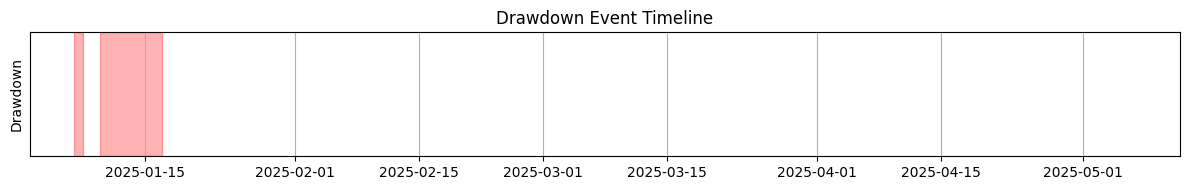

<ipython-input-17-f1922a8537d6>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_drawdown = drawdown.resample('M').min()


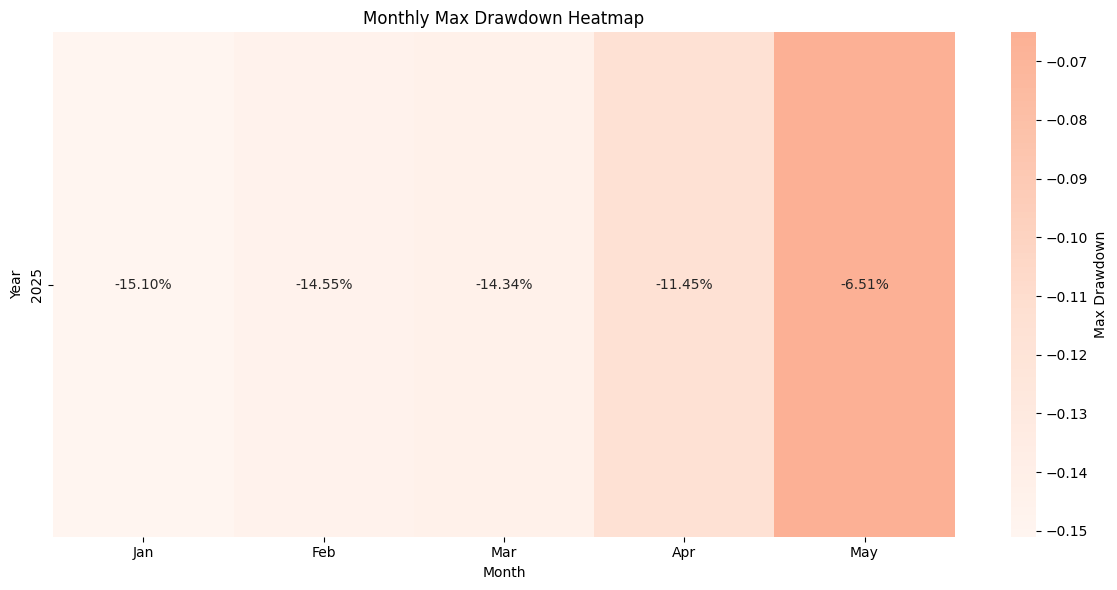

In [17]:
# 计算每一段 drawdown 的持续时间
drawdown_duration = []
current_duration = 0

for i in range(1, len(drawdown)):
    if drawdown.iloc[i] < 0:
        current_duration += 1
    else:
        if current_duration > 0:
            drawdown_duration.append(current_duration)
            current_duration = 0

# 可视化持续时间分布
plt.figure(figsize=(10, 4))
plt.hist(drawdown_duration, bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title('Drawdown Duration Distribution')
plt.xlabel('Drawdown Duration (Days)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# 找出所有 drawdown 段的起点和终点
in_drawdown = False
start_idx = None
dd_periods = []

for i in range(len(drawdown)):
    if drawdown.iloc[i] < 0 and not in_drawdown:
        in_drawdown = True
        start_idx = drawdown.index[i]
    elif drawdown.iloc[i] == 0 and in_drawdown:
        end_idx = drawdown.index[i]
        dd_periods.append((start_idx, end_idx))
        in_drawdown = False

# 画时间线：红条标出 drawdown 区间
plt.figure(figsize=(12, 2))
for start, end in dd_periods:
    plt.axvspan(start, end, color='red', alpha=0.3)
plt.xlim(drawdown.index[0], drawdown.index[-1])
plt.title('Drawdown Event Timeline')
plt.ylabel('Drawdown')
plt.yticks([])
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

import seaborn as sns
import calendar

# Step 1: 计算每月最大回撤
monthly_dd = cumulative_return.resample('D').ffill().copy()

# 每日 high watermark
rolling_max = monthly_dd.cummax()
drawdown = monthly_dd - rolling_max

# 按月计算每月最大 drawdown（最负的值）
monthly_drawdown = drawdown.resample('M').min()

# Step 2: 整理成 heatmap 格式
monthly_drawdown_df = monthly_drawdown.to_frame(name='Drawdown')
monthly_drawdown_df['Year'] = monthly_drawdown_df.index.year
monthly_drawdown_df['Month'] = monthly_drawdown_df.index.month
pivot = monthly_drawdown_df.pivot(index='Year', columns='Month', values='Drawdown')

# 将月份列名转为文字形式（Jan, Feb...）
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

# Step 3: 绘图
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.2%', center=0, cbar_kws={'label': 'Max Drawdown'})
plt.title('Monthly Max Drawdown Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


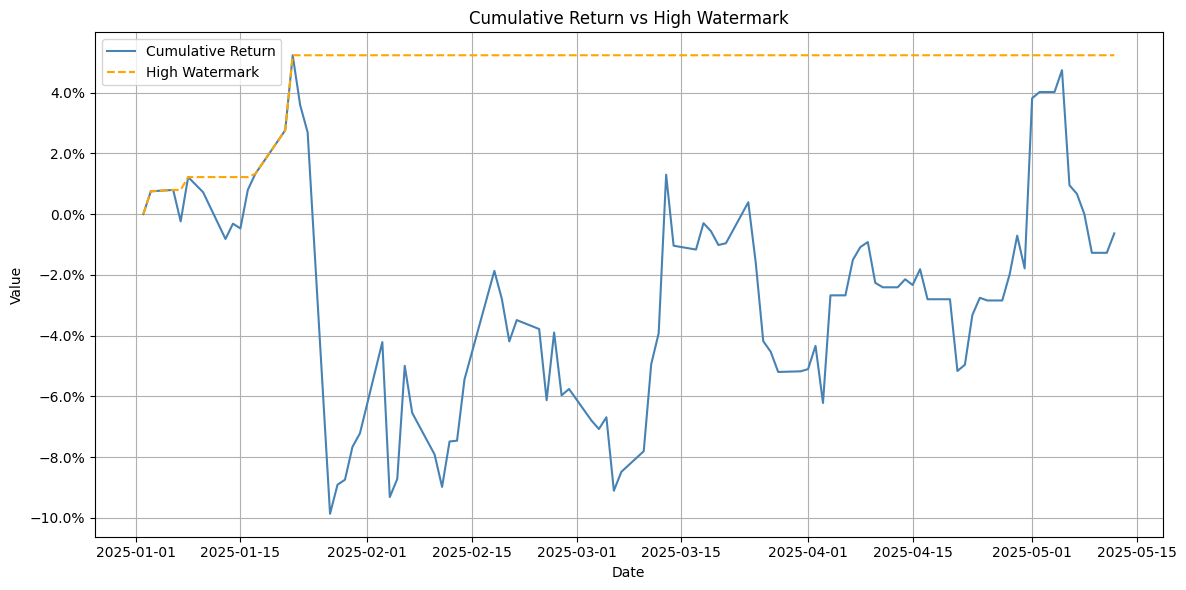

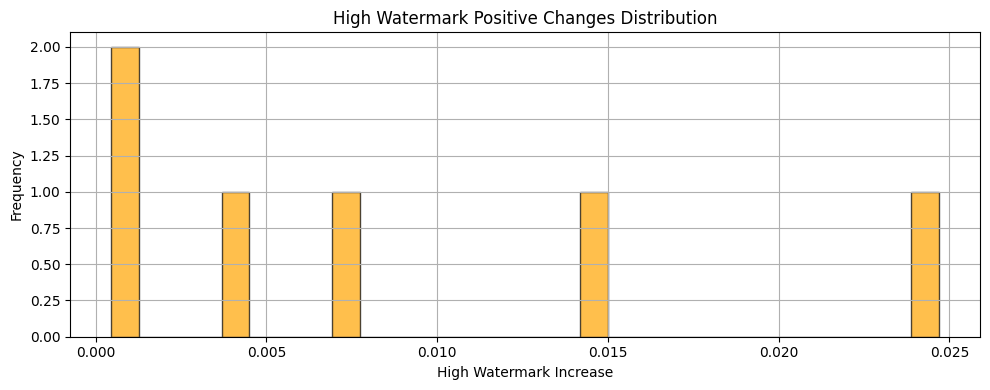

In [14]:
# === Step 10: 计算 High Watermark（累计收益的滚动最大值）===
high_watermark = cumulative_return.cummax()

# === Step 11: 绘图：High Watermark vs Cumulative Return ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_return, label='Cumulative Return', color='steelblue')
plt.plot(high_watermark, label='High Watermark', color='orange', linestyle='--')

plt.title('Cumulative Return vs High Watermark')
plt.xlabel('Date')
plt.ylabel('Value')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 12: 计算 High Watermark 的变化幅度 ===
hw_diff = high_watermark.diff().dropna()
hw_positive_jumps = hw_diff[hw_diff > 0]  # 只分析突破时刻

# === Step 13: 分布图 ===
plt.figure(figsize=(10, 4))
plt.hist(hw_positive_jumps, bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('High Watermark Positive Changes Distribution')
plt.xlabel('High Watermark Increase')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()



**每次新高（High Watermark）突破时，相比上一次新高，累计收益增长了多少百分比：

**

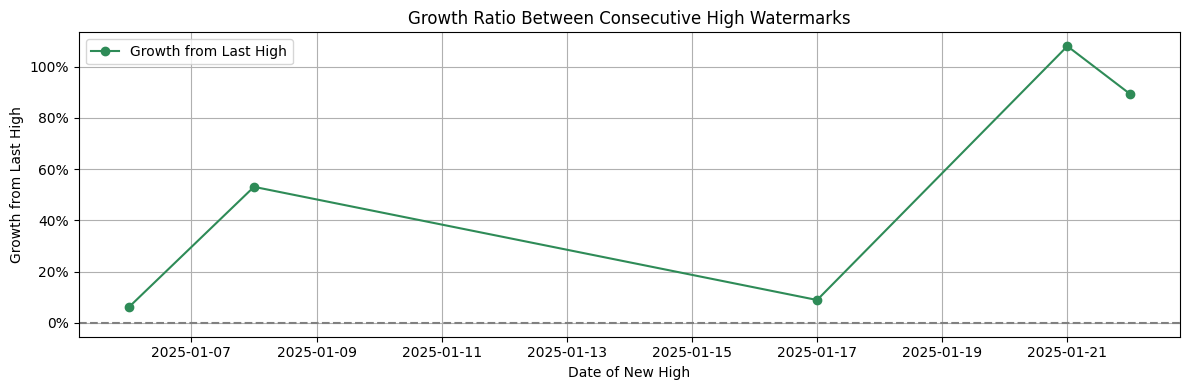

🔍 找到的新高时间点: [Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-06 00:00:00'), Timestamp('2025-01-08 00:00:00'), Timestamp('2025-01-17 00:00:00'), Timestamp('2025-01-21 00:00:00'), Timestamp('2025-01-22 00:00:00')]


In [43]:
# Step 1: 获取 high watermark 序列
high_watermark = cumulative_return.cummax()

# Step 2: 找出每次出现新高的时间点（跳跃点）
breakthrough_dates = high_watermark[high_watermark > high_watermark.shift(1)].index

# Step 3: 计算每次新高相对前一新高的百分比增幅
ratios = []
dates = []

for i in range(1, len(breakthrough_dates)):
    prev_date = breakthrough_dates[i - 1]
    curr_date = breakthrough_dates[i]

    prev_val = cumulative_return.loc[prev_date]
    curr_val = cumulative_return.loc[curr_date]

    if prev_val != 0:
        growth = (curr_val - prev_val) / abs(prev_val)
        ratios.append(growth)
        dates.append(curr_date)

# Step 4: 绘图（时间序列版）
plt.figure(figsize=(12, 4))
plt.plot(dates, ratios, marker='o', linestyle='-', color='seagreen', label='Growth from Last High')
plt.axhline(0, linestyle='--', color='gray')
plt.title('Growth Ratio Between Consecutive High Watermarks')
plt.xlabel('Date of New High')
plt.ylabel('Growth from Last High')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("🔍 找到的新高时间点:", breakthrough_dates.tolist())




📈 拟合斜率: 每1%回撤 ≈ 增加 69.97 天恢复


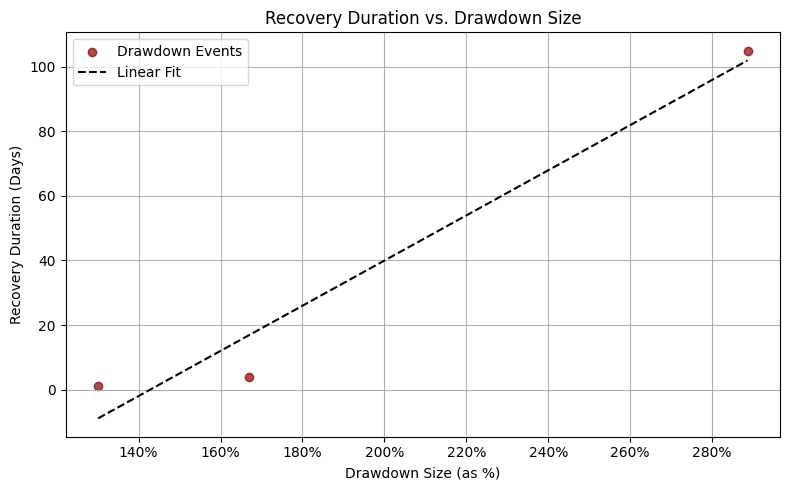

In [38]:
# === Step: 构建 high watermark 和 drawdown ===
high_watermark = cumulative_return.cummax()
drawdown = cumulative_return - high_watermark

# === Step: 自动识别所有 drawdown 段 ===
in_drawdown = False
drawdown_events = []

for date in drawdown.index:
    val = drawdown.loc[date]
    cum_val = cumulative_return.loc[date]
    hwm_val = high_watermark.loc[date]

    if val < 0:
        if not in_drawdown:
            in_drawdown = True
            peak_date = date
            peak_val = hwm_val
            trough_val = cum_val
            trough_date = date
        elif cum_val < trough_val:
            trough_val = cum_val
            trough_date = date
    else:
        if in_drawdown:
            recovery_date = date
            dd_size = (trough_val - peak_val) / peak_val
            drawdown_events.append((peak_date, trough_date, recovery_date, dd_size))
            in_drawdown = False

# ✅ 如果最后还没恢复，记录到最后为止
if in_drawdown:
    recovery_date = drawdown.index[-1]
    dd_size = (trough_val - peak_val) / peak_val
    drawdown_events.append((peak_date, trough_date, recovery_date, dd_size))

    import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from sklearn.linear_model import LinearRegression

# 提取 recovery duration 和 drawdown size
recovery_durations = []
drawdown_depths = []

for peak, trough, recovery, size in drawdown_events:
    duration = (recovery - trough).days
    if duration >= 0:
        recovery_durations.append(duration)
        drawdown_depths.append(abs(size))

# 画图 + 拟合线
plt.figure(figsize=(8, 5))
plt.scatter(drawdown_depths, recovery_durations, color='darkred', alpha=0.7, label='Drawdown Events')

if len(drawdown_depths) > 1:
    X = np.array(drawdown_depths).reshape(-1, 1)
    y = np.array(recovery_durations)
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    plt.plot(X, y_pred, color='black', linestyle='--', label='Linear Fit')
    print(f"📈 拟合斜率: 每1%回撤 ≈ 增加 {model.coef_[0]:.2f} 天恢复")

plt.title('Recovery Duration vs. Drawdown Size')
plt.xlabel('Drawdown Size (as %)')
plt.ylabel('Recovery Duration (Days)')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




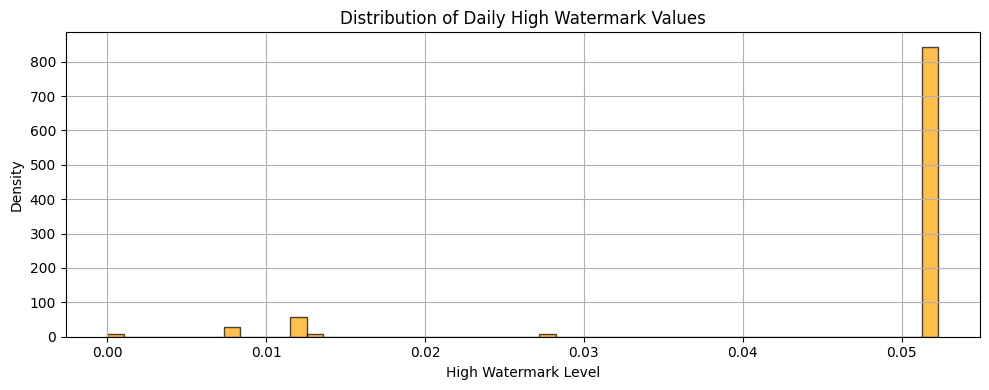

In [39]:
# 概率密度分布图（High Watermark 值的密度）
plt.figure(figsize=(10, 4))
plt.hist(high_watermark, bins=50, color='orange', edgecolor='black', alpha=0.7, density=True)
plt.title('Distribution of Daily High Watermark Values')
plt.xlabel('High Watermark Level')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
# === Step 1: 基础变量 ===
cumulative = cumulative_return.copy()
high_watermark = cumulative.cummax()
drawdown = cumulative - high_watermark

# === Step 2: 找最大回撤点和之前高点 ===
min_dd_date = drawdown.idxmin()
min_dd_value = drawdown.loc[min_dd_date]
peak_before_min = high_watermark.loc[:min_dd_date].max()

# === Step 3: 找从该点之后第一次超过前高的点 ===
recovery_candidate = cumulative[cumulative > peak_before_min].loc[min_dd_date:]
recovery_date = recovery_candidate.first_valid_index()

# === Step 4: 判断有没有恢复 ===
if recovery_date is None:
    print("❌ 从最大回撤之后还没有恢复到前高，无法绘制恢复期 High Watermark 图。")
else:
    # === Step 5: 提取恢复区间内的 High Watermark ===
    recovery_period = high_watermark.loc[min_dd_date:recovery_date]

    # === Step 6: 绘图 ===
    plt.figure(figsize=(12, 4))
    plt.plot(recovery_period, color='forestgreen', label='High Watermark (Recovery Period)')
    plt.title(f'High Watermark Recovery Trend\nFrom Max Drawdown on {min_dd_date.date()} to Recovery on {recovery_date.date()}')
    plt.xlabel('Date')
    plt.ylabel('High Watermark')
    plt.axvline(min_dd_date, color='red', linestyle='--', label='Max Drawdown')
    plt.axvline(recovery_date, color='blue', linestyle='--', label='Recovery Point')
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 补充：输出恢复所需天数
    recovery_days = (recovery_date - min_dd_date).days
    print(f"✅ 从最大回撤恢复到前高共用了 {recovery_days} 天")


❌ 从最大回撤之后还没有恢复到前高，无法绘制恢复期 High Watermark 图。


**A -> C  two high watermark dist  **

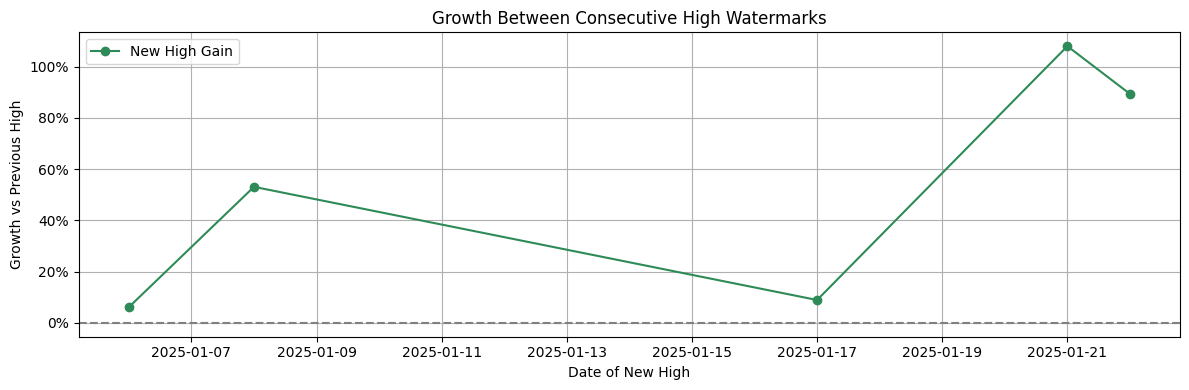

In [42]:
# Step 1: 计算 high watermark
high_watermark = cumulative_return.cummax()

# Step 2: 找出每次突破前高的位置（即 hwm 上升的点）
breakthrough_dates = high_watermark[high_watermark > high_watermark.shift(1)].index

# Step 3: 计算两次新高之间的 % 增长
hw_growths = []
hw_dates = []

for i in range(1, len(breakthrough_dates)):
    prev = cumulative_return.loc[breakthrough_dates[i-1]]
    curr = cumulative_return.loc[breakthrough_dates[i]]
    growth = (curr - prev) / abs(prev) if prev != 0 else 0
    hw_growths.append(growth)
    hw_dates.append(breakthrough_dates[i])  # 当前新高时间

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12, 4))
plt.plot(hw_dates, hw_growths, marker='o', linestyle='-', color='seagreen', label='New High Gain')
plt.axhline(0, linestyle='--', color='gray')

plt.title('Growth Between Consecutive High Watermarks')
plt.xlabel('Date of New High')
plt.ylabel('Growth vs Previous High')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
# Step 1: 用户输入起止日期
start_date = input("请输入起始日期 (yyyy-mm-dd): ")
end_date = input("请输入结束日期 (yyyy-mm-dd): ")

# Step 2: 限定分析区间
cumulative = cumulative_return.loc[start_date:end_date]
high_watermark = cumulative.cummax()
drawdown = cumulative - high_watermark

# Step 3: 找所有 drawdown 段的最大值（局部 peak → trough）
in_drawdown = False
current_peak = None
current_trough = None
drawdown_sizes = []
drawdown_events = []

for date in drawdown.index:
    value = drawdown.loc[date]

    if value < 0:
        if not in_drawdown:
            in_drawdown = True
            current_peak = high_watermark.loc[date]
            current_trough = cumulative.loc[date]
            peak_date = date
            trough_date = date  # ✅ 初始化
        else:
            if cumulative.loc[date] < current_trough:
                current_trough = cumulative.loc[date]
                trough_date = date  # ✅ 更新最小值
    else:
        if in_drawdown and 'trough_date' in locals():
            dd_size = (current_trough - current_peak) / current_peak
            recovery_date = date
            drawdown_sizes.append(dd_size)
            drawdown_events.append((peak_date, trough_date, recovery_date, dd_size))
            in_drawdown = False

# Step 4: 绘图（回撤大小的直方图）
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.figure(figsize=(10, 4))
plt.hist(drawdown_sizes, bins=20, color='crimson', edgecolor='black', alpha=0.7)
plt.title(f'Drawdown Size Distribution ({start_date} to {end_date})')
plt.xlabel('Drawdown Size (as %)')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: 画累计收益曲线 + 标注 drawdown 关键点
plt.figure(figsize=(12, 4))
plt.plot(cumulative, label='Cumulative Return', color='steelblue', linewidth=2)

for peak, trough, recovery, size in drawdown_events:
    plt.scatter(peak, cumulative.loc[peak], color='green')
    plt.scatter(trough, cumulative.loc[trough], color='red')
    plt.scatter(recovery, cumulative.loc[recovery], color='orange')

    plt.annotate('Peak', (peak, cumulative.loc[peak]), textcoords="offset points", xytext=(0, 10), ha='center', color='green')
    plt.annotate('Trough', (trough, cumulative.loc[trough]), textcoords="offset points", xytext=(0, -15), ha='center', color='red')
    plt.annotate('Recovery', (recovery, cumulative.loc[recovery]), textcoords="offset points", xytext=(0, 10), ha='center', color='orange')

plt.title(f'Cumulative Return with Drawdown Annotations ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: 输出统计信息
if drawdown_sizes:
    print(f"📊 回撤次数: {len(drawdown_sizes)}")
    print(f"🔻 平均回撤: {np.mean(drawdown_sizes):.2%}")
    print(f"💥 最大单次回撤: {np.min(drawdown_sizes):.2%}")
else:
    print("✅ 在这个时间段内没有发生回撤")


KeyboardInterrupt: Interrupted by user

In [34]:
total_durations = []
drop_durations = []
recovery_durations = []

for peak, trough, recovery, _ in drawdown_events:
    total_durations.append((recovery - peak).days)
    drop_durations.append((trough - peak).days)
    recovery_durations.append((recovery - trough).days)
